# Projekt: Przewidywanie awarii maszyn (Predictive Maintenance)
## Część 1: Wybór zbioru danych i wstępny import

### Wybór zbioru i uzasadnienie:
Wybraliśmy zbiór danych **AI4I 2020 Predictive Maintenance Dataset**. Jest to syntetyczny zbiór danych odzwierciedlający realne parametry z czujników maszyn przemysłowych (frezarek).

**Dlaczego ten zbiór?**
1. **Adekwatność do problemu:** Zawiera zarówno parametry ciągłe (temperatura, obroty), jak i flagę awarii. Idealnie nadaje się do metod sztucznej inteligencji (klasyfikacja binarna).
2. **Kontekst biznesowy:** Pozwala na rozwiązanie realnego problemu – zamiast naprawiać maszynę, gdy już się zepsuje model ma nas ostrzec wcześniej.


In [1]:
import pandas as pd
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"


df = pd.read_csv(url)


df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [2]:

print("INFORMACJE O TYPACH ZMIENNYCH")
df.info()
print("ANALIZA BRAKÓW W DANYCH")
missing_values = df.isnull().sum()
print(missing_values)

INFORMACJE O TYPACH ZMIENNYCH
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64 

### Słownik Danych (Opis zmiennych telemetrycznych)

Zbiór danych AI4I 2020 symuluje parametry pracy przemysłowej frezarki (maszyny CNC). Poniżej znajduje się fizyczna i biznesowa interpretacja poszczególnych cech (kolumn), z którymi będziemy pracować:

* **Type (Klasa jakości maszyny):** Zmienna kategoryczna określająca jakość wykonania maszyny. Przyjmuje wartości: L-Low,M-Medium,H-High Maszyny niższej jakości są z reguły bardziej podatne na usterki.
* **Air temperature [K] (Temperatura otoczenia):** Temperatura powietrza panująca w hali produkcyjnej. Podana jest w Kelwinach (aby przeliczyć ją na stopnie Celsjusza, należy odjąć 273.15, co oznacza, że średnia temperatura w hali wynosi około 27°C).
* **Process temperature [K] (Temperatura procesu):** Temperatura samego wrzeciona maszyny i strefy obróbki metalu. W wyniku tarcia jest ona zawsze o kilka stopni wyższa niż temperatura otoczenia.
* **Rotational speed [rpm] (Prędkość obrotowa):** Liczba obrotów wrzeciona (z zamontowanym narzędziem tnącym) na minutę. Wysokie obroty są wymagane przy precyzyjnej obróbce, ale mogą generować wyższe temperatury.
* **Torque [Nm] (Moment obrotowy):** "Siła skręcająca" układu napędowego. Wskazuje, z jakim oporem materiału musi radzić sobie maszyna. Nagły wzrost momentu obrotowego często świadczy o tępym narzędziu lub zbyt twardym materiale.
* **Tool wear [min] (Zużycie narzędzia):** Skumulowany czas pracy (w minutach) aktualnie zamontowanego narzędzia tnącego (np. frezu). Im dłuższy czas, tym narzędzie jest bardziej stępione, co drastycznie obciąża maszynę i prowadzi do awarii.
* **Machine failure (Awaria maszyny):** Nasza zmienna docelowa (Target / Zmienna objaśniana). Klasa **0** oznacza prawidłową pracę, natomiast **1** oznacza wystąpienie krytycznej usterki, która zatrzymała proces produkcyjny.

**Wniosek z weryfikacji zbioru:**
Zbiór składa się z 10 000 wierszy i 14 kolumn. Dane są w 100% kompletne – funkcja `isnull()` nie wykryła żadnych braków (NaN). Dzięki temu możemy pominąć etap uzupełniania danych i od razu przejść do selekcji cech.


### Selekcja cech i zapobieganie zjawisku wycieku danych

Przed przystąpieniem do głębszej analizy statystycznej, musimy oczyścić zbiór z kolumn, które mogłyby zaburzyć proces uczenia modelu:

1. **Usunięcie identyfikatorów :**
   Kolumny `UDI` oraz `Product ID` to unikalne kody  maszyn. Algorytmy sztucznej inteligencji opierają się na matematyce – szukanie wzorców w losowych identyfikatorach mogłoby prowadzić do przeuczenia modelu.

2. **Pułapka wycieku danych **
   Naszym zadaniem jest przewidywanie awarii (`Machine failure`). Zbiór zawiera jednak 5 dodatkowych kolumn na samym końcu (`TWF`, `HDF`, `PWF`, `OSF`, `RNQ`), które są flagami informującymi o *konkretnej przyczynie* awarii (np. HDF to przegrzanie).
   Zostawienie ich w zbiorze treningowym doprowadziłoby do tzw. **wycieku danych**. W rzeczywistości produkcyjnej, przed wystąpieniem awarii, nie mamy informacji o tym, z jakiego powodu ona nastąpi. Wpuszczenie tych kolumn do modelu sprawiłoby, że model "oszukiwałby", mając informacje z przyszłości.

Zostawiamy wyłącznie "czyste" parametry z czujników maszyn (temperatura, obroty, moment obrotowy, zużycie narzędzia) oraz flagę awarii.

In [3]:

kolumny_do_usuniecia = ['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']


df = df.drop(columns=kolumny_do_usuniecia, errors='ignore')

print("Kolumny pozostawione do analizy i modelowania:")
print(df.columns.tolist())

Kolumny pozostawione do analizy i modelowania:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']




Przed budową modeli sprawdzamy zakresy wartości dla poszczególnych czujników (m.in. średnią, wartości minimalne i maksymalne). Pozwala to wykryć ewentualne anomalie fizyczne (np. ujemną temperaturę w Kelwinach, co oznaczałoby błąd czujnika).

Następnie badamy rozkład zmiennej docelowej (`Machine failure`). W przypadku danych przemysłowych awarie są zazwyczaj zdarzeniami rzadkimi, co prowadzi do problemu niezbalansowanych klas (Imbalanced Data).

=== STATYSTYKI OPISOWE CZUJNIKÓW ===


,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.0,0.0,0.0,1.0


/tmp/ipykernel_7569/3677189419.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Machine failure', palette='Set2')


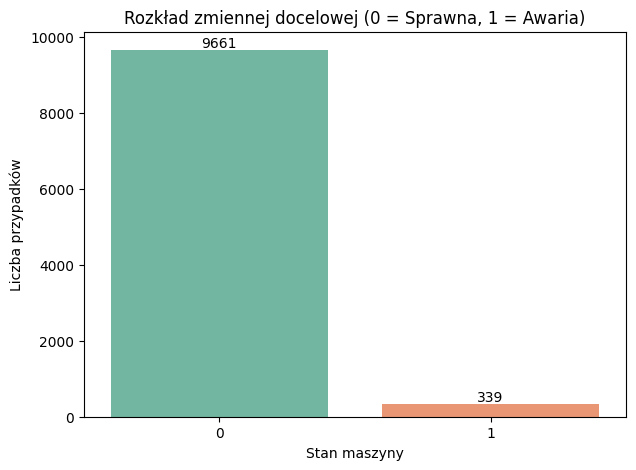

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("=== STATYSTYKI OPISOWE CZUJNIKÓW ===")
display(df.describe().T)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('Rozkład zmiennej docelowej (0 = Sprawna, 1 = Awaria)')
plt.xlabel('Stan maszyny')
plt.ylabel('Liczba przypadków')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

**Wnioski z analizy statystycznej i balansu klas:**
1. Czujniki nie wykazują fizycznych anomalii (np. temperatury w Kelwinach mieszczą się w standardowych, dodatnich zakresach około 300K).


### Wybór metryki ewaluacyjnej:

Z uwagi na drastyczne niezbalansowanie klas w naszym zbiorze (96.6% maszyn sprawnych względem 3.4% awarii), ocena modeli sztucznej inteligencji na podstawie klasycznej metryki **Accuracy (Dokładność)** byłaby błędem metodologicznym. Zjawisko to w analizie danych nazywane jest *Paradoksem Dokładności*.

**Dowód logiczny (Model Naiwny):**
Gdybyśmy zdefiniowali algorytm, który całkowicie ignoruje odczyty z czujników telemetrycznych i dla każdego przypadku domyślnie przewiduje brak awarii (zawsze zwraca klasę 0), jego dokładność wyniosłaby matematyczne 96.6%. Choć wynik ten wydaje się niezwykle wysoki, taki model byłby biznesowo bezużyteczny – przegapiłby 100% faktycznych usterek na linii produkcyjnej.

**Decyzja projektowa:**
W fazie implementacyjnej (Szkolenie i optymalizacja modeli) odrzucamy *Accuracy* jako główne kryterium oceny. Naszym celem będzie optymalizacja modeli pod kątem:
1. **Recall (Czułość):** Mierzy, jaki odsetek spośród wszystkich rzeczywistych awarii (339 przypadków) nasz model zdołał poprawnie wykryć. Z perspektywy *Predictive Maintenance* zależy nam na maksymalizacji tej metryki, ponieważ koszt weryfikacji fałszywego alarmu (False Positive) jest znikomy w porównaniu z kosztem zniszczenia maszyny i przestoju produkcji (False Negative).
2. **F1-Score:** Średnia harmoniczna z precyzji (Precision) i czułości (Recall), która pozwoli nam na sprawiedliwą ocenę ogólnej jakości modeli na tak trudnym, niezbalansowanym zbiorze danych.

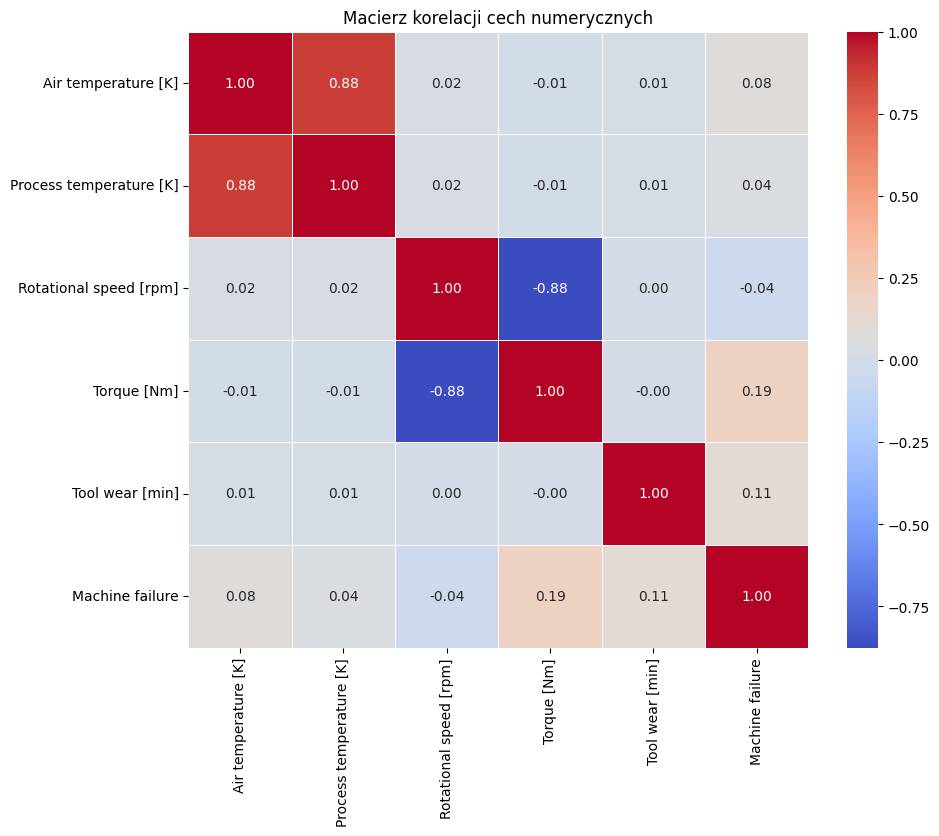

In [5]:

kolumny_numeryczne = df.select_dtypes(include=['float64', 'int64'])

macierz_korelacji = kolumny_numeryczne.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(macierz_korelacji, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji cech numerycznych')
plt.show()

 ### Wnioski z macierzy korelacji i Inżynieria Cech

**Obserwacje z heatmapy:**
1. Zmienna docelowa (`Machine failure`) jest najsilniej dodatnio skorelowana z momentem obrotowym (`Torque`, 0.19) oraz zużyciem narzędzia (`Tool wear`, 0.11).
2. Zauważono zjawisko silnej korelacji dodatniej (0.88) pomiędzy temperaturą otoczenia a temperaturą procesu.
3. Występuje silna korelacja ujemna (-0.88) pomiędzy prędkością obrotową a momentem obrotowym, co odzwierciedla fizykę pracy wrzeciona.

**Działanie korygujące (Feature Engineering):**
Aby zredukować multikolinearność i dostarczyć modelowi bardziej syntetyczną informację, tworzymy nową cechę: `Temperature_difference` (różnica między temperaturą procesu a otoczenia), która lepiej odzwierciedla faktyczne nagrzewanie się maszyny podczas pracy.

In [6]:

df['Temperature_difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']

df = df.drop(columns=['Air temperature [K]', 'Process temperature [K]'])

print("Zaktualizowana lista cech po Inżynierii Cech:")
print(df.columns.tolist())

Zaktualizowana lista cech po Inżynierii Cech:
['Type', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'Temperature_difference [K]']


###  Sformułowanie hipotezy badawczej i biznesowej

**Hipoteza badawcza (H1):**
Zakładamy, że zastosowanie algorytmów uczenia maszynowego (w szczególności modeli opartych na zespołach drzew decyzyjnych) na wyselekcjonowanych danych telemetrycznych pozwoli na skuteczną klasyfikację i predykcję stanów awaryjnych maszyn (zmienna `Machine failure`).

**Cel optymalizacyjny:**
Ze względu na silne niezbalansowanie klas (awarie stanowią tylko 3.4% przypadków), model nie będzie oceniany pod kątem ogólnej dokładności (Accuracy). Głównym celem jest maksymalizacja metryki **Czułości**

**Uzasadnienie biznesowe:**
W zagadnieniu *Predictive Maintenance* pominięcie faktycznej awarii (błąd fałszywie negatywny / False Negative) generuje ogromne koszty przestoju maszyny na linii produkcyjnej. Fałszywe alarmy (False Positive), skutkujące jedynie niepotrzebnym sprawdzeniem maszyny przez technika, są biznesowo znacznie tańsze. Skuteczne wdrożenie takiego modelu umożliwi przedsiębiorstwu przejście z kosztownej konserwacji reaktywnej na przewidywalną i zaplanowaną konserwację predykcyjną.

###  Aktualny stan wiedzy

W tradycyjnym przemyśle utrzymanie ruchu opierało się zazwyczaj na dwóch wariantach:
1. **Run-to-Failure (Konserwacja reaktywna):** Naprawa maszyny dopiero po jej zepsuciu.
2. **Preventive Maintenance (Konserwacja prewencyjna):** Rutynowa wymiana części po określonym czasie, niezależnie od ich faktycznego zużycia, co generuje niepotrzebne koszty.

Obecnie branża Przemysłu 4.0 przechodzi na rozwiązania **Predictive Maintenance (PdM)** z wykorzystaniem metod sztucznej inteligencji (AI) i Internetu Rzeczy (IoT).

**Przegląd algorytmów:**
W przypadku przemysłowych danych tabelarycznych (takich jak rozpatrywany zbiór AI4I 2020), proste modele liniowe (np. Regresja Logistyczna) często zawodzą z powodu nieliniowych relacji fizycznych między czujnikami (np. dynamika nagrzewania się maszyny przy różnym obciążeniu).

